## BERT 모델 파인튜닝

대화 데이터셋 정의

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' # Off TensorFlow logging (1: errors, 2: warnings, 3: info)

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW

conversation_data = [
    {"question": "Hello", "answer": "Hi, I'm an LLM student. Who are you?"},
    {"question": "What can you do?", "answer": "I can answer a variety of questions."},
    {"question": "How's the weather?", "answer": "The weather isn't available where I am."},
    {"question": "How old are you?", "answer": "I'm not old, but I try to provide up-to-date information."},
    {"question": "What do you like to do?", "answer": "I like analyzing data and providing information."}
]

MODEL_NAME = "distilbert-base-uncased" # https://huggingface.co/distilbert/distilbert-base-uncased
label_to_answer = {i: item["answer"] for i, item in enumerate(conversation_data)}

def gen_model(question): # 질문에 대한 답변을 생성하는 함수
    # Intent classification -> fixed answer retrieval
    encoded_input = tokenizer(
        question,
        max_length=64,
        padding="max_length",
        truncation=True,
        return_tensors="pt",
    )

    input_ids = encoded_input["input_ids"].to(device)
    attention_mask = encoded_input["attention_mask"].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        predicted_label = torch.argmax(outputs.logits, dim=-1).item()

    output_text = label_to_answer[predicted_label]
    return output_text

c:\ProgramData\miniconda3\envs\venv_lmm\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.3.0) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


데이터셋 클래스 정의

In [2]:
class ConversationDataset(Dataset):
    def __init__(self, tokenizer, data, max_length=64):
        self.tokenizer = tokenizer
        self.data = data
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        # Classify question into one of predefined answer labels.
        question_tokens = self.tokenizer(
            item["question"],
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids": question_tokens["input_ids"].squeeze(0),
            "attention_mask": question_tokens["attention_mask"].squeeze(0),
            "labels": torch.tensor(idx, dtype=torch.long),  # 질문별 정답 클래스
        }


토크나이저 및 데이터셋 준비

In [3]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
dataset = ConversationDataset(tokenizer, conversation_data)
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

모델 및 옵티마이저 준비

In [4]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(conversation_data),
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Optimizer 설정
optimizer = AdamW(model.parameters(), lr=5e-5)

decoded_output = gen_model("Hello")
print(f"\n모델 학습 전 테스트\nInput: Hello")
print(f"Output: {decoded_output}")


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



모델 학습 전 테스트
Input: Hello
Output: I can answer a variety of questions.


모델 학습

In [5]:
losses = []
epochs = 50
model.train()
for epoch in range(epochs):
    for batch in dataloader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        # Forward pass
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        losses.append(loss.item())

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        print(f"Epoch {epoch + 1}, Loss: {loss.item()}")

# 모델 저장
model_path = "./conversation_bert_mlm_model"
tokenizer_path = "./conversation_bert_tokenizer"
model.save_pretrained(model_path)
tokenizer.save_pretrained(tokenizer_path)

print(f"Model saved to {model_path}")
print(f"Tokenizer saved to {tokenizer_path}")

Epoch 1, Loss: 1.6216998100280762
Epoch 1, Loss: 1.5757181644439697
Epoch 1, Loss: 1.8242290019989014
Epoch 2, Loss: 1.6215972900390625
Epoch 2, Loss: 1.4618682861328125
Epoch 2, Loss: 1.5015552043914795
Epoch 3, Loss: 1.325378179550171
Epoch 3, Loss: 1.5593812465667725
Epoch 3, Loss: 1.4135221242904663
Epoch 4, Loss: 1.2499743700027466
Epoch 4, Loss: 1.3379796743392944
Epoch 4, Loss: 1.5933330059051514
Epoch 5, Loss: 1.2081475257873535
Epoch 5, Loss: 1.3220372200012207
Epoch 5, Loss: 1.020301342010498
Epoch 6, Loss: 0.9457117319107056
Epoch 6, Loss: 1.1483709812164307
Epoch 6, Loss: 0.944832444190979
Epoch 7, Loss: 0.861265242099762
Epoch 7, Loss: 0.8920689225196838
Epoch 7, Loss: 0.7735955715179443
Epoch 8, Loss: 0.6747710704803467
Epoch 8, Loss: 0.8341052532196045
Epoch 8, Loss: 0.6705304980278015
Epoch 9, Loss: 0.5952818393707275
Epoch 9, Loss: 0.7550382614135742
Epoch 9, Loss: 0.46345412731170654
Epoch 10, Loss: 0.434211790561676
Epoch 10, Loss: 0.5755153894424438
Epoch 10, Loss: 

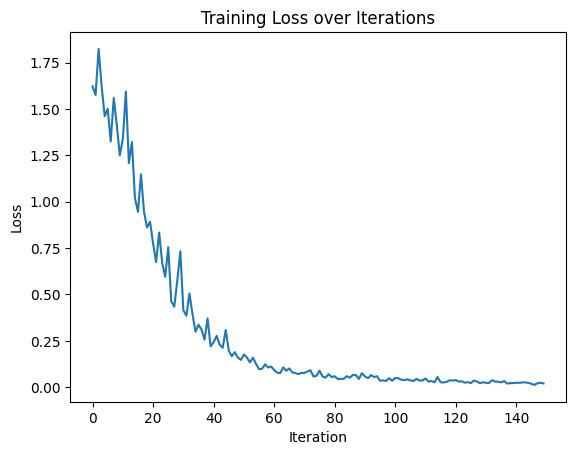

In [6]:
import matplotlib.pyplot as plt
plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss over Iterations')
plt.show()

파인튜닝 모델, 토크나이저 로드 및 테스트

In [7]:
model = AutoModelForSequenceClassification.from_pretrained(model_path)
tokenizer = AutoTokenizer.from_pretrained(tokenizer_path)
model.to(device)

# 파인튜닝 모델 테스트
model.eval()

inference_text =  "Hello."
decoded_output = gen_model(inference_text)
print(f"\n전체 파인튜닝(Full Fine-Tuning) 후 결과\nInput: {inference_text}")
print(f"Output: {decoded_output}")


전체 파인튜닝(Full Fine-Tuning) 후 결과
Input: Hello.
Output: Hi, I'm an LLM student. Who are you?
